# Cross-Asset Macro Volatility 

**Author:** Grant Reed 

**Date:** March 8, 2026 

---

## Harvesting the Volatility Risk Premium 
In this analysis, we implement a **cross-asset relative value volatility strategy** to harvest the spread between implied and realized volatility - the **Volatility Risk Premium (VRP)** - across a diversified macroeconomic universe (Equities, Gold, Oil, FX, and High-Yield Credit). 

**Signal:** A rolling Z-score identifies relative-value pairs.

**P&L Modeling:** Daily option returns are derived from a second-order Taylor Series expansion, utilizing Black-Scholes Greeks to isolate volatility returns from underling price movements. 

**Risk Management:** After evaluating an equal-weight baseline on the long/short legs, we implement an **inverse-volatility weighting framework** to equalize risk contributions across assets. This dynamic scaling delivers superior risk-adjusted returns and significantly shallower drawdowns.

In [1]:
# Ensure notebook updates automatically without restarting the kernel after updating .py library module. 
%load_ext autoreload 
%autoreload 2
import library_code as lc # imports helper/plotting functions from our .py library module 

import yfinance as yf 
import pandas as pd
import pandas_datareader.data as pdr
import numpy as np

from scipy.optimize import curve_fit
from scipy.stats import norm

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from IPython.display import display

import datetime
import itertools 
import os
import seaborn as sns

## 1. Data Assembly 
We construct our asset universe using highly liquid ETFS and their corresponding "VIX-style" implied volatility indices. 
the raw ingestion logic (FRED and Yahoo Finance) is abstracted into a local library, with the primary dataset loaded from a .parquet file. 

### 1.1 Core Components 
**Implied Volatility ($\sigma_{IV}$):** Sourced from standardized CBOE and exchange-traded indices (e.g., ^VIX, ^GVZ, ^EVZ).
* These values represent annualized 30-day implied volatility as a percentage.
* Note: These indices reflect market expectations over the next 30 calendar days, necessitating specific treatment when aligning with trading-day returns.

**Spot Assets ($S_t$):** Daily adjusted closing prices for liquid proxies of five distinct macro classes: 
* **Equities:** S&P 500 (SPY)
* **Metals / Safe Haven:** Gold (GLD)
* **Energy:** Crude Oil (USO)
* **Currencies:** Euro FX (FXE)
* **Credit:** High-Yield Corporate Bonds (HYG) 

### 1.2 Benchmarks
We include external volatility benchmarks (DBMF, SVXY, VXX) to evaluate our strategy's performance relative to common volatility-risk-premia harvesters.

In [2]:
data = pd.read_parquet('market_data.parquet', engine='pyarrow') # import implied volatility, spot asset, and benchmark data from .parquet file 
data.head(2) # check first few rows 

,Spot_Euro,Spot_Gold,Spot_HighYield,Spot_Equity,Spot_Oil,IV_Euro,IV_Gold,IV_Oil,IV_Equity,IV_HighYield,DBMF,SVXY,VXX
Date,,,,,,,,,,,,,
2008-08-01,145.653748,89.570000,31.714642,91.239204,808.320007,8.93,24.73,46.830002,22.57,8.13,NaN,NaN,NaN
2008-08-04,146.112808,88.139999,31.495985,90.393005,780.159973,9.27,25.42,48.000000,23.49,8.14,NaN,NaN,NaN


Initial NaN values observed in the DBMF, SVXY, and VXX columns are expected and reflect their historical inception dates (e.g., DBMF launched in 2019).

### 1.3  Risk-Free Rates: LIBOR & SOFR 
We integrate a historical "risk-free" rate ($r_f$) to ensure the accuracy of our derivative pricing and portfolio accounting. 
* We utilize the 3-Month LIBOR for the pre-2022 period and the 3-Month SOFR for the modern era.

In [3]:
df_rates = pd.read_parquet('libor_sofr.parquet', engine='pyarrow') # import implied volatility, spot asset, and benchmark data from .parquet file
df_rates.head(2)

,3M LIBOR/SOFR
Date,
1986-01-02,0.0800
1986-01-03,0.0806


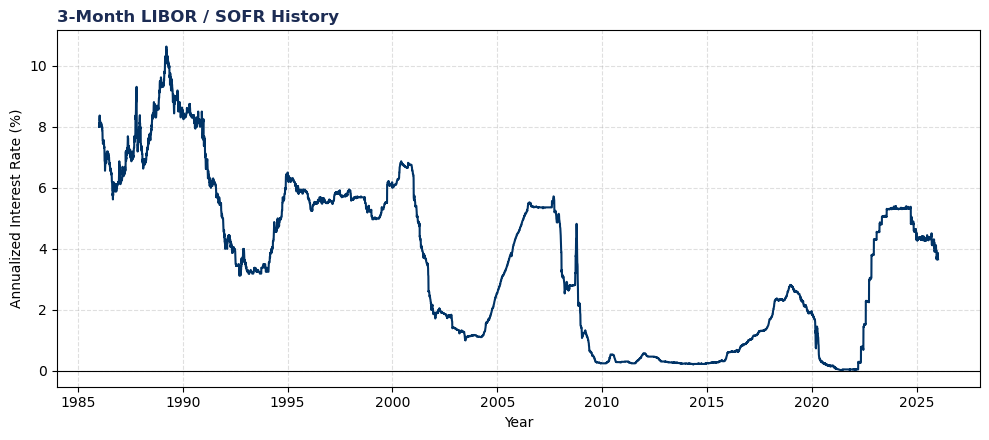

In [4]:
# Execute Plot
lc.plot_risk_free_rates(df_rates)

Our strategy employs a **synthetic option framework**, allowing our principal capital to remain **unencumbered.**
* Unlike a cash-equity approach, we do not deploy the principal to purchase assets; instead, we record daily PnL as the mark-to-market change in contract values (Greeks).
* This allows the full principal amount to be held in a collateral account accruing the risk-free rate ($r_f$), 

## 2. Universal Functions

### 2.1 Feature Engineering 
This function calculates the **Volatility Risk Premium (VRP)** and its corresponding **Z-Score**, which serves as the core signal for our strategy.

**Realized Volatility ($\sigma_{RV}$):** 
* Annualized standard deviation of log returns over a rolling 21-day window.

* $\sigma_{RV} = \text{std}(\ln(P_t / P_{t-1})) \times \sqrt{252} \times 100$

**Volatility Risk Premium (VRP):** 
* Structural spread between forward-looking implied volatility ($\sigma_{IV}$) and backward-looking realized volatility ($\sigma_{RV}$).

* $VRP = \sigma_{IV} - \sigma_{RV}$

In [5]:
def get_features(market_data, rv_window=21, z_window=252):
    # Work on a copy to avoid mutating the original raw data
    df = market_data.copy()
    
    # 1. Dynamically identify all Spot columns
    spot_cols = [col for col in df.columns if 'Spot_' in col]
    
    # 2. Calculate Realized Volatility (RV)
    returns = np.log(df[spot_cols] / df[spot_cols].shift(1))
    rv_df = returns.rolling(window=rv_window).std() * np.sqrt(252) * 100
    
    # Rename RV columns and merge into main dataframe
    rv_rename_dict = {col: col.replace('Spot_', 'RV_') for col in spot_cols}
    rv_df = rv_df.rename(columns=rv_rename_dict)
    df = pd.concat([df, rv_df], axis=1)
    
    # Track our newly created Z-score columns for the safe drop
    z_cols_generated = []
    
    # 3. Calculate VRP and Z-Scores dynamically for each asset
    for spot_col in spot_cols:
        asset = spot_col.replace('Spot_', '')
        iv_col = f'IV_{asset}'
        rv_col = f'RV_{asset}'
        vrp_col = f'VRP_{asset}'
        z_col = f'Z_{asset}'
        
        # Only proceed if the corresponding IV data exists
        if iv_col in df.columns:
            # A. Calculate VRP (Implied - Realized)
            df[vrp_col] = df[iv_col] - df[rv_col]
            
            # B. Calculate rolling distribution of VRP
            rolling_mean = df[vrp_col].rolling(window=z_window).mean()
            rolling_std = df[vrp_col].rolling(window=z_window).std()
            
            # C. Calculate Z-Score (shifted to prevent look-ahead bias)
            df[z_col] = (df[vrp_col] - rolling_mean.shift(1)) / rolling_std.shift(1)
            
            # Add to our tracking list
            z_cols_generated.append(z_col)
        
    # ONLY drop rows where our core Z-scores are NaN (the 253-day burn-in).
    # This preserves 2009-2019 data even if SVXY or DBMF are NaN during those years.
    return df.dropna(subset=z_cols_generated)

To normalize the VRP across our asset universe, we implement a 252-day rolling Z-Score:

$Z_t = \frac{VRP_t - \mu_{t-1}}{\sigma_{t-1}}$
* **1-Day Lag:** We apply the shift(1) operator to the rolling mean and standard deviation.
* **Preventing Bias:** This ensures the signal is tradable at the market open using only information available as of the prior-day close.


In [6]:
master_data = get_features(data) 
master_data[[col for col in master_data.columns if 'Z_' in col]].tail(3)

,Z_Euro,Z_Gold,Z_HighYield,Z_Equity,Z_Oil
Date,,,,,
2025-03-03,-1.005620,0.241232,0.699861,1.347663,1.572745
2025-03-04,-1.347487,0.308941,0.850730,1.422190,1.372407
2025-03-05,-1.733409,0.227814,0.781130,0.860690,0.592441


We have successfully calculated the 252-day rolling Z-Scores for each asset class

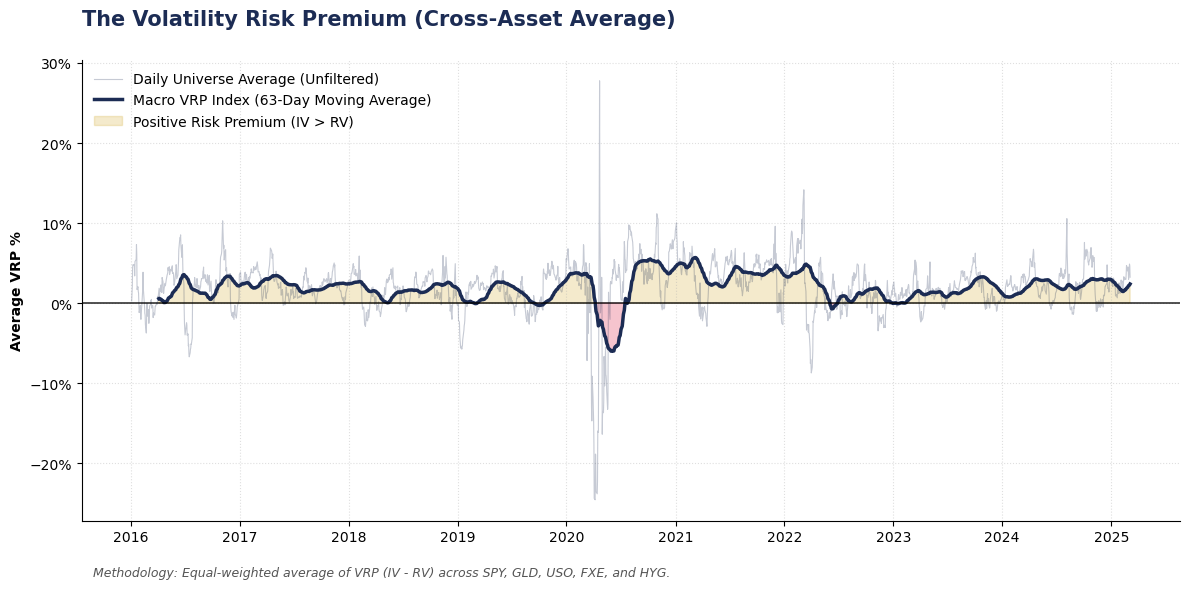

In [7]:
lc.plot_vrp(master_data, start_date='2016-01-01', end_date='2025-12-31')

### 2.2 Greek Approximation  
We approximate daily PnL through a second-order Taylor Series Expansion.

For each asset in our relative value pair (Short and Long), the daily PnL of the straddle position is estimated as:

$\text{Daily PnL} \approx \underbrace{\left( \frac{1}{2} \Gamma \cdot (\Delta S)^2 \right)}_{\text{Gamma PnL}} + \underbrace{\left( \mathcal{V} \cdot \Delta \sigma \right)}_{\text{Vega PnL}} + \underbrace{\Theta}_{\text{Theta PnL}}$

* **Gamma ($\Gamma$):** The non-linear "convexity" cost/gain from price movements in the underlying spot asset.
* **Vega ($\mathcal{V}$):** The impact of a 1-percentage-point shift in the implied volatility index.
* **Theta ($\Theta$):** The daily "rent" or time decay collected (for short positions) or paid (for long positions).


The following function derives these sensitivities using the Black-Scholes-Merton (1973) framework. 
* It assumes an At-The-Money (ATM) synthetic straddle with a constant 30-day time-to-maturity ($T = 30/365$). 

In [8]:
def calculate_greeks(spot, strike, time_to_maturity, iv, rate):
    # Protect against division by zero as expiration approaches
    T = max(time_to_maturity, 1e-5) 
    S = spot
    K = strike
    sigma = iv / 100.0  # Convert IV from percentage to decimal
    r = rate            # Risk-free rate (already decimal)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    pdf_d1 = norm.pdf(d1)
    cdf_d2 = norm.cdf(d2)
    cdf_neg_d2 = norm.cdf(-d2)
    
    # Gamma (doubled for straddle)
    gamma_single = pdf_d1 / (S * sigma * np.sqrt(T))
    straddle_gamma = 2 * gamma_single
    
    # Vega (doubled, divided by 100 for a 1-point IV move)
    vega_single = S * np.sqrt(T) * pdf_d1
    straddle_vega = (2 * vega_single) / 100.0
    
    # Theta (daily decay, divided by 252)
    theta_common = -(S * sigma * pdf_d1) / (2 * np.sqrt(T))
    call_theta = theta_common - r * K * np.exp(-r * T) * cdf_d2
    put_theta = theta_common + r * K * np.exp(-r * T) * cdf_neg_d2
    straddle_theta = (call_theta + put_theta) / 252.0
    
    return straddle_gamma, straddle_vega, straddle_theta

### 2.3 Backtesting Engine 
This function integrates Z-score signals, Greek-based PnL attribution, and risk constraints into a unified time-series simulation.


**Daily Relative Value (RV):** 
* Each day, the model identifies the "expensive" volatility (highest Z-score) to short and the "cheap" (lowest Z-score) to long.

**Friction & Funding**
* **Hedging Costs:** A basis-point penalty (friction_bps) applied to estimated shares traded to simulate daily delta-hedging.
* **Borrow Costs:** Structural cost of maintaining short-leg exposure.
* **Cash Yield:** "Total Return" accounting accrues interest on unencumbered capital at risk-free rate ($r_f$).

**Spread Gate:** Trades are only executed if the spread between the long and short Z-scores exceeds a user-defined z_threshold, ensuring we only deploy capital when the relative value opportunity is statistically significant.


**Dynamic Sizing:** The engine supports both Equal-Weight and Risk Parity (Inverse-Volatility) allocation. Risk Parity dynamically scales notional exposure based on the prior-day realized volatility ($\sigma_{RV}$) of each leg to equalize the risk contribution across the pair.

In [9]:
def run_backtest(master_df, df_rates, initial_capital=10000000, leverage=2.0, friction_bps=0.0005, short_borrow_rate=0.005, z_threshold=0.0, start_date=None, end_date=None, sizing_method='equal'):
    
    capital = initial_capital
    ledger = []
    
    # 1. Align dates across the Master Data and the Rates Data
    common_dates = master_df.index.intersection(df_rates.index).sort_values()
    
    # Filter the dates based on user input
    if start_date is not None:
        common_dates = common_dates[common_dates >= pd.to_datetime(start_date)]
    if end_date is not None:
        common_dates = common_dates[common_dates <= pd.to_datetime(end_date)]
        
    # Safety check
    if len(common_dates) < 2:
        print("Warning: Not enough overlapping dates in the specified range to run the backtest.")
        return pd.DataFrame()
        
    ttm = 30.0 / 365 # Constant 30-day proxy
    
    # Pre-identify Z-score columns to avoid searching for them inside the loop
    z_cols = [col for col in master_df.columns if col.startswith('Z_')]
    
    for i in range(1, len(common_dates)):
        today = common_dates[i]
        yesterday = common_dates[i-1]
        
        # PRO-TIP: Extract the full row once per day to drastically speed up the loop
        yest_data = master_df.loc[yesterday]
        today_data = master_df.loc[today]
        
        # 2. Signals & Rates
        yesterday_z = yest_data[z_cols]
        
        max_z = yesterday_z.max()
        short_asset = yesterday_z.idxmax().replace('Z_', '')
        
        min_z = yesterday_z.min()
        long_asset = yesterday_z.idxmin().replace('Z_', '')
        
        z_spread = max_z - min_z
        daily_rate = df_rates.loc[yesterday, '3M LIBOR/SOFR']
        
        # 3. Capital Allocation & Sizing
        gross_exposure = capital * leverage
        
        if z_spread >= z_threshold:
            if sizing_method == 'risk_parity':
                # Pull directly from the extracted row
                rv_short = yest_data[f'RV_{short_asset}']
                rv_long = yest_data[f'RV_{long_asset}']
                
                inv_rv_short = 1.0 / rv_short
                inv_rv_long = 1.0 / rv_long
                total_inv_rv = inv_rv_short + inv_rv_long
                
                weight_short = inv_rv_short / total_inv_rv
                weight_long = inv_rv_long / total_inv_rv
                
                notional_s = gross_exposure * weight_short
                notional_l = gross_exposure * weight_long
                
            else:
                notional_s = gross_exposure / 2.0
                notional_l = gross_exposure / 2.0
        else:
            notional_s = 0
            notional_l = 0
            
        # Initialize daily metrics to zero
        gamma_pnl_s = vega_pnl_s = theta_pnl_s = gross_pnl_short = hedging_cost_s = borrow_cost_s = net_pnl_short = 0
        gamma_pnl_l = vega_pnl_l = theta_pnl_l = gross_pnl_long = hedging_cost_l = net_pnl_long = 0
        
        # ==========================================
        # 4. The Spread Gate (Trade BOTH or NEITHER)
        # ==========================================
        if z_spread >= z_threshold:
            
            # --- SHORT LEG ---
            spot_yest_s = yest_data[f'Spot_{short_asset}']
            spot_today_s = today_data[f'Spot_{short_asset}']
            iv_yest_s = yest_data[f'IV_{short_asset}']
            iv_today_s = today_data[f'IV_{short_asset}']
            
            shares_s = notional_s / spot_yest_s  
            gamma_s, vega_s, theta_s = calculate_greeks(spot_yest_s, spot_yest_s, ttm, iv_yest_s, daily_rate)
            
            dS_s = spot_today_s - spot_yest_s
            dIV_s = iv_today_s - iv_yest_s
            
            gamma_pnl_s = -1 * (0.5 * gamma_s * (dS_s**2)) * shares_s
            vega_pnl_s = -1 * (vega_s * dIV_s) * shares_s
            theta_pnl_s = -1 * theta_s * shares_s
            gross_pnl_short = gamma_pnl_s + vega_pnl_s + theta_pnl_s
            
            shares_traded_s = abs(gamma_s * dS_s * shares_s)
            hedging_cost_s = shares_traded_s * spot_today_s * friction_bps
            
            borrow_cost_s = notional_s * (short_borrow_rate / 252.0) 
            net_pnl_short = gross_pnl_short - hedging_cost_s - borrow_cost_s
            
            # --- LONG LEG ---
            spot_yest_l = yest_data[f'Spot_{long_asset}']
            spot_today_l = today_data[f'Spot_{long_asset}']
            iv_yest_l = yest_data[f'IV_{long_asset}']
            iv_today_l = today_data[f'IV_{long_asset}']
            
            shares_l = notional_l / spot_yest_l  
            gamma_l, vega_l, theta_l = calculate_greeks(spot_yest_l, spot_yest_l, ttm, iv_yest_l, daily_rate)
            
            dS_l = spot_today_l - spot_yest_l
            dIV_l = iv_today_l - iv_yest_l
            
            gamma_pnl_l = (0.5 * gamma_l * (dS_l**2)) * shares_l
            vega_pnl_l = (vega_l * dIV_l) * shares_l
            theta_pnl_l = theta_l * shares_l
            gross_pnl_long = gamma_pnl_l + vega_pnl_l + theta_pnl_l
            
            shares_traded_l = abs(gamma_l * dS_l * shares_l)
            hedging_cost_l = shares_traded_l * spot_today_l * friction_bps
            net_pnl_long = gross_pnl_long - hedging_cost_l
            
        else:
            short_asset = 'None' 
            long_asset = 'None' 
            
        # ==========================================
        # 5. Aggregation & Ledger
        # ==========================================
        cash_yield = capital * (daily_rate / 252.0)
        daily_net_pnl = net_pnl_short + net_pnl_long + cash_yield
        capital += daily_net_pnl
        
        ledger.append({
            'Date': today,
            'Short_Asset': short_asset,
            'Long_Asset': long_asset,
            'Total_Gamma_PnL': gamma_pnl_s + gamma_pnl_l,
            'Total_Vega_PnL': vega_pnl_s + vega_pnl_l,
            'Total_Theta_PnL': theta_pnl_s + theta_pnl_l,
            'Gross_PnL_Short': gross_pnl_short,
            'Gross_PnL_Long': gross_pnl_long,
            'Hedging_Costs': hedging_cost_s + hedging_cost_l,
            'Borrow_Costs': borrow_cost_s,
            'Cash_Yield': cash_yield,
            'Daily_Net_PnL': daily_net_pnl,
            'Capital': capital
        })
        
    return pd.DataFrame(ledger).set_index('Date')

### 2.4 Performance Reporting 
This function transforms raw ledger data into a comprehensive summary table: 
* **Risk-Adjusted Metrics**: Calculates annualized returns, volatility, Sharpe ratio, and maximum drawdown 
* **P&L Composition:** Breaks total profits into constituent parts: Gross Option PnL, Cash Yield, Hedging Costs, and Borrow Costs.
* **Activity:** Tracks total trading days and active days %. 

In [10]:
def get_performance(results_df, strategy_name="2.0x VRP Macro", initial_capital=10000000):
    res = results_df.copy()
    res['Daily_Return'] = res['Capital'].pct_change()
    
    # 1. Performance & Risk Math
    total_return = (res['Capital'].iloc[-1] / initial_capital) - 1
    ann_return = (1 + total_return) ** (252 / len(res)) - 1
    ann_vol = res['Daily_Return'].std() * np.sqrt(252)
    sharpe = (res['Daily_Return'].mean() * 252) / ann_vol if ann_vol != 0 else 0
    max_dd = ((res['Capital'] - res['Capital'].cummax()) / res['Capital'].cummax()).min()
    
    # 2. Activity Metrics (Simpler, more transparent)
    active_days = res[res['Short_Asset'] != 'None'].shape[0]
    pct_active = active_days / len(res)
    
    # 3. The PnL Bridge Components
    gross_opt_pnl = res['Total_Gamma_PnL'].sum() + res['Total_Vega_PnL'].sum() + res['Total_Theta_PnL'].sum()
    cash_yield = res['Cash_Yield'].sum()
    hedge_costs = res['Hedging_Costs'].sum()
    borrow_costs = res['Borrow_Costs'].sum()
    net_pnl = res['Daily_Net_PnL'].sum()
    
    # 4. Create Structured DataFrame
    stats = {
        'Ann Return': f"{ann_return:.2%}",
        'Ann Vol': f"{ann_vol:.2%}",
        'Sharpe': f"{sharpe:.2f}",
        'Max DD': f"{max_dd:.2%}",
        'Active Days %': f"{pct_active:.1%}",
        'Trading Days': f"{active_days:,}", # Updated from Total Trades
        
        'Gross Opt PnL': f"${gross_opt_pnl:,.0f}",
        'Cash Yield': f"${cash_yield:,.0f}",
        'Hedge Costs': f"-${hedge_costs:,.0f}",
        'Borrow Costs': f"-${borrow_costs:,.0f}",
        
        'Net PnL': f"<b>${net_pnl:,.0f}</b>",
        'Final Equity': f"<b>${res['Capital'].iloc[-1]:,.0f}</b>"
    }
    
    summary = pd.DataFrame(stats, index=[strategy_name])
    
    # 5. Visual "Gold Standard" Styling
    styled_df = summary.style.set_properties(**{
        'text-align': 'center', 
        'padding': '14px',
        'border': '1px solid #eeeeee',
        'color': '#000000' # Global Black Text
    }).set_table_styles([
        
        # Header Styling: Professional Navy & Gold
        {'selector': 'thead th', 'props': [
            ('background-color', '#1C2C54 !important'), 
            ('color', 'white !important'), 
            ('font-weight', 'bold'), 
            ('text-transform', 'uppercase'),
            ('letter-spacing', '1px'),
            ('border-bottom', '3px solid #d4af37 !important'), # GOLD ACCENT
            ('text-align', 'center'),
            ('border', '1px solid #1C2C54')
        ]},
        
        # Row Labels: Modern subtle gray
        {'selector': 'tbody th', 'props': [
            ('text-align', 'left'), 
            ('font-weight', 'bold'),
            ('background-color', '#ffffff !important'),
            ('color', '#333333'),
            ('padding-right', '20px'),
            ('border-right', '1px solid #dee2e6')
        ]},
        
        # Highlight: PnL Bridge (Gross to Costs) - Light Yellow/Gold
        {'selector': 'td.col6, td.col7, td.col8, td.col9', 'props': [
            ('background-color', '#fffdf0')
        ]},
        
        # Highlight: Final Results (Net PnL & Equity) - Light Blue Focus
        {'selector': 'td.col10, td.col11', 'props': [
            ('background-color', '#f0f7ff'),
            ('font-weight', 'bold'),
            ('color', '#1C2C54')
        ]},
        
        # Section Dividers (Vertical)
        {'selector': 'td.col5, thead th.col5', 'props': [('border-right', '2px solid #aaa !important')]},
        {'selector': 'td.col9, thead th.col9', 'props': [('border-right', '2px solid #aaa !important')]}
        
    ], overwrite=True) # Forces removal of any default Jupyter CSS
    
    return styled_df

## 3. Initial Backtest
We establish a **baseline performance** using a "naive" **equal-weight allocation** across all available trading days, with no signal filtering (threshold = 0).

### 3.1 Capital Efficiency & Leverage
We utilize a synthetic option framework rather than physical cash-equity positions, resulting in higher capital efficiency:
* **Prime Brokerage Framework:** We assume a $\$10\text{M}$ cash-collateralized account.
* **Notional Exposure:** The broker permits a 2.0x leverage factor, allowing us to "write" (sell) and "buy" straddles representing $\$20\text{M}$ in underlying ETF notional value.
* **Margin Mechanics:** Trading ATM straddles does not require the full notional value of the underlying asset. Instead, we post a fraction of the value as Initial Margin, leaving the remaining cash unencumbered to accrue the risk-free rate.

In [11]:
# Run initial backtest
results_df = run_backtest(
    master_df = master_data, 
    df_rates=df_rates, 
    initial_capital=10000000, 
    leverage=2.0, 
    z_threshold=0, # <-- Z-Score Spread Threshold (set to 0 ensures active for all days) 
    start_date = '2015-01-01', end_date = '2025-12-31', # <-- Start / End Dates 
    sizing_method = 'equal') # <-- Equal-Weight Allocation 

In [12]:
get_performance(results_df, strategy_name = "VRP Equal-Weight")

,Ann Return,Ann Vol,Sharpe,Max DD,Active Days %,Trading Days,Gross Opt PnL,Cash Yield,Hedge Costs,Borrow Costs,Net PnL,Final Equity
VRP Equal-Weight,11.72%,16.94%,0.75,-28.56%,100.0%,"2,557","$23,187,802","$4,004,898","-$5,621,214","-$782,434","$20,789,050","$30,789,050"


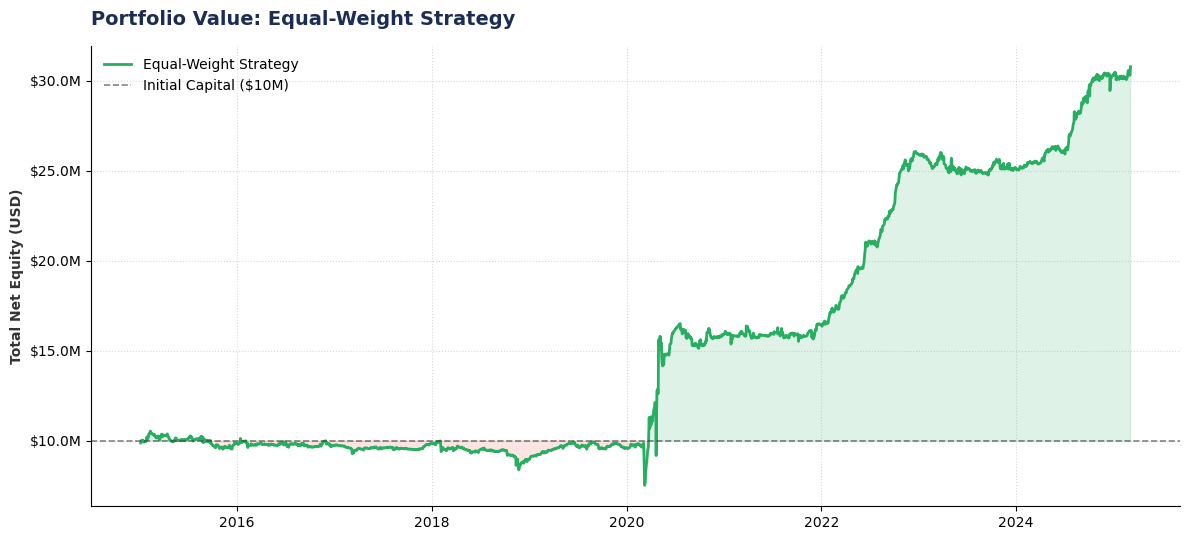

In [13]:
lc.plot_equity(results_df, strategy_name = 'Equal-Weight Strategy')

### 3.2 Historical Drawdown Analysis 
The drawdown profile measures the percentage decline from the portfolio’s previous high-water mark. 
* Unless the current close is an all-time high, the strategy is mathematically in a drawdown.

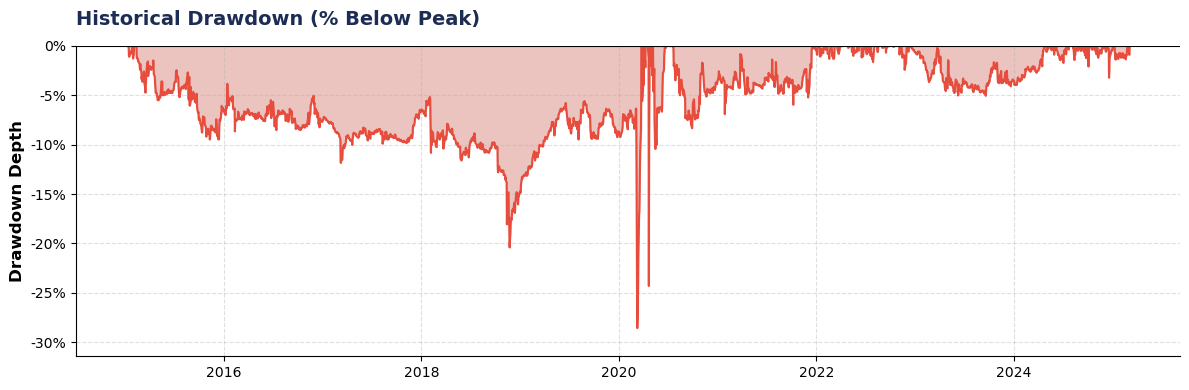

In [14]:
lc.plot_drawdown(results_df)

The drawdown in early 2020 highlights our equal-weight strategy's  **vulnerability to correlated volatility spikes across asset classes.** 
* During this period, realized volatility surged past implied expectations (VRP Inversion), triggering significant Vega and Gamma losses on our short-volatility legs.
* In our next section, we examine if scaling our positions based on volatility (Risk Parity) could help mitigate these losses. 

In [15]:
lc.get_asset_attribution(results_df)

,Short_Vol_PnL,Long_Vol_PnL,Total_Asset_PnL
HighYield,"$-1,633,283","$9,786,771","$8,153,488"
Oil,"$10,604,289","$-4,371,805","$6,232,484"
Euro,"$3,299,965","$2,040,188","$5,340,152"
Equity,"$4,843,781","$-1,528,874","$3,314,907"
Gold,"$2,930,859","$-2,784,089","$146,771"
Total Option Gross PnL,"$20,045,610","$3,142,191","$23,187,802"


**High-Yield Credit (HYG)**  served as a powerful long-volatility hedge during credit stress, while **Crude Oil** provided the most consistent harvest for our Short Volatility (VRP) leg.

In [16]:
lc.get_greek_attribution(results_df)

,,PnL Contribution
Gamma,Price Curvature,"$5,620,894"
Vega,Implied Volatility,"$16,379,988"
Theta,Time Decay,"$1,186,920"
Total Option Gross PnL,,"$23,187,802"


The Vega PnL confirms our strategy's alpha is driven by the reversion of Implied Volatility (IV) toward realized levels.

The  Gamma PnL reflects gains from the underlying spot price staying within the "expected range" defined by our straddle strikes, allowing us to harvest the price-action premium.

## 4. Inverse Volatility (Risk Parity) Weighting
Our baseline backtest allocated capital equally across the two selected assets each day, ignoring their varying risk profiles.

We now implement an **Inverse-Volatility (Risk Parity)** weighting scheme to equalize the risk contribution across the portfolio.

### 4.1 Methodology 
Initial capital remains $\$10\text{M}$, the notional distribution between the long and short legs shifts daily based on the assets selected:
* **Dynamic Scaling:** We scale the notional exposure of each leg based on its 30-day Realized Volatility ($\sigma_{RV}$).
* **Risk Balancing:** Low-volatility assets (HYG or FXE) receive higher notional weight. High-volatility assets (Oil or Equity) are "deleveraged." 

In [17]:
res_eq = run_backtest(
    master_df = master_data, 
    df_rates=df_rates, 
    initial_capital=10000000, 
    leverage=2.0,
    z_threshold=0,
    start_date = '2015-01-01', end_date = '2025-12-31',
    sizing_method = 'equal' )

res_rp = run_backtest(
    master_df = master_data, 
    df_rates=df_rates, 
    initial_capital=10000000, 
    leverage=2.0,
    z_threshold=0,
    start_date = '2015-01-01', end_date = '2025-12-31',
    sizing_method = 'risk_parity' )

In [18]:
lc.get_strategy_comparison(res_eq, res_rp)

,Ann Return,Ann Vol,Sharpe,Max DD,Active Days %,Trading Days,Gross Opt PnL,Cash Yield,Hedge Costs,Borrow Costs,Net PnL,Final Equity
Equal Weight,11.72%,16.94%,0.75,-28.56%,100.0%,"2,557","$23,187,802","$4,004,898","-$5,621,214","-$782,434","$20,789,050","$30,789,050"
Inverse Vol.,14.00%,9.21%,1.47,-11.79%,100.0%,"2,557","$31,222,293","$4,925,044","-$7,220,029","-$1,144,495","$27,782,813","$37,782,813"


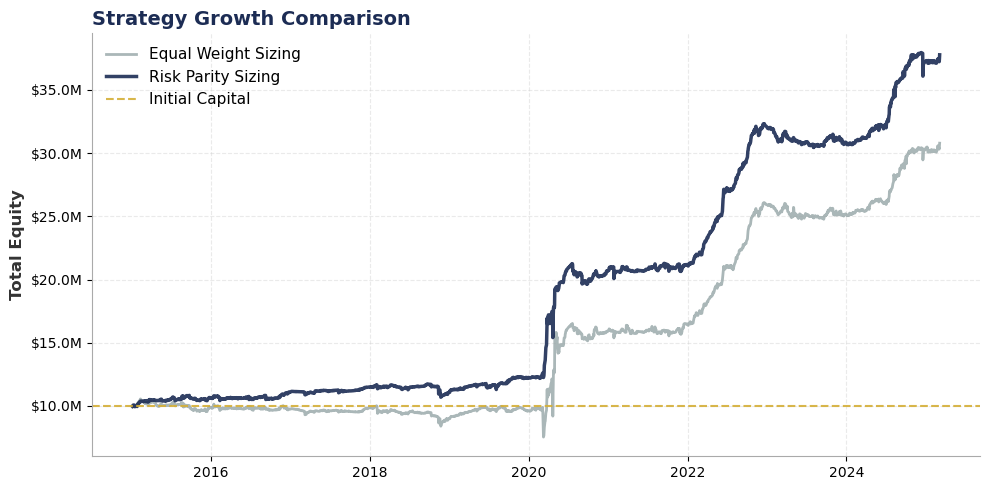

In [19]:
lc.plot_comparison_window(master_data, df_rates, start_date='2015-01-01', end_date='2025-12-31', 
                           z_thresh=0.0, initial_capital=10000000)

We observe our Risk-Parity strategy produces greater annualized returns over our analysis period. 

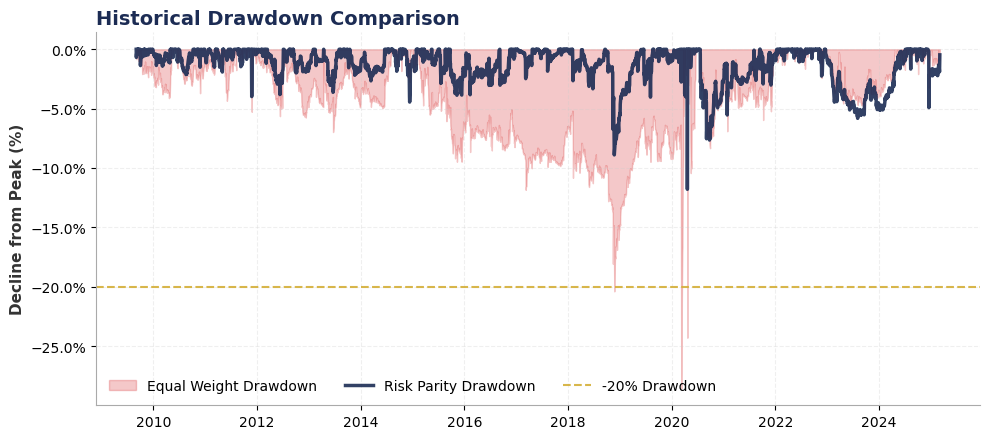

In [20]:
lc.plot_drawdown_comparison(master_data, df_rates, 
                         start_date='2009-01-01', end_date='2025-12-31')

## 5. Z-Score Spread Threshold Analysis
We now isolate the **impact of the Z-score spread** magnitude on portfolio returns. 

By tightening our requirements to $|Z| > 1.5$ or $2.0$, we quantify the trade-off between higher selectivity and the resulting reduction in total trading days.

In [21]:
lc.get_sensitivity_table(master_data, df_rates, sizing_method='risk_parity', thresholds=None)

,Ann Return,Ann Vol,Sharpe,Max DD,Active Days %,Trading Days,Gross Opt PnL,Cash Yield,Hedge Costs,Borrow Costs,Net PnL,Final Equity
Z-Spread ≥ 0.0,13.87%,8.30%,1.61,-11.79%,100.0%,"3,900","$74,394,067","$9,991,979","-$16,987,106","-$2,780,961","$64,617,979","$74,617,979"
Z-Spread ≥ 0.5,13.59%,8.29%,1.58,-11.79%,99.3%,"3,872","$71,293,571","$9,675,675","-$16,434,027","-$2,698,372","$61,836,847","$71,836,847"
Z-Spread ≥ 1.0,13.30%,8.13%,1.58,-11.79%,89.8%,"3,504","$66,810,333","$9,357,761","-$14,725,178","-$2,420,712","$59,022,205","$69,022,205"
Z-Spread ≥ 1.5,12.69%,7.84%,1.56,-11.34%,68.9%,"2,689","$57,725,069","$8,715,843","-$11,123,885","-$1,807,433","$53,509,594","$63,509,594"
Z-Spread ≥ 2.0,12.59%,7.46%,1.63,-11.34%,47.2%,"1,839","$53,468,016","$8,586,328","-$8,115,144","-$1,279,441","$52,659,758","$62,659,758"
Z-Spread ≥ 2.5,10.50%,7.20%,1.42,-11.34%,31.5%,"1,229","$35,484,071","$6,743,706","-$4,629,304","-$696,513","$36,901,961","$46,901,961"


### 5.1 Sensitivity Results 
The Z-Spread ≥ 2.0 threshold achieves the highest risk-adjusted return (1.63 Sharpe)
* However, the improvement over the baseline (Z-Spread ≥ 0) is marginal.
* Given that **the baseline maintains a competitive Sharpe (1.60)** with significantly higher total Net PnL, **we utilize our baseline parameters for the remainder of this analysis.**

## 6. Benchmarks & Risk Correlation 
We evaluate our strategy's performance relative to broader market benchmarks.

### 6.1 Equity Benchmark: S&P 500 
We benchmark our Risk-Parity Strategy VRP Macro against the S&P 500 (SPY) over a 10-year horizon (2015–2025).

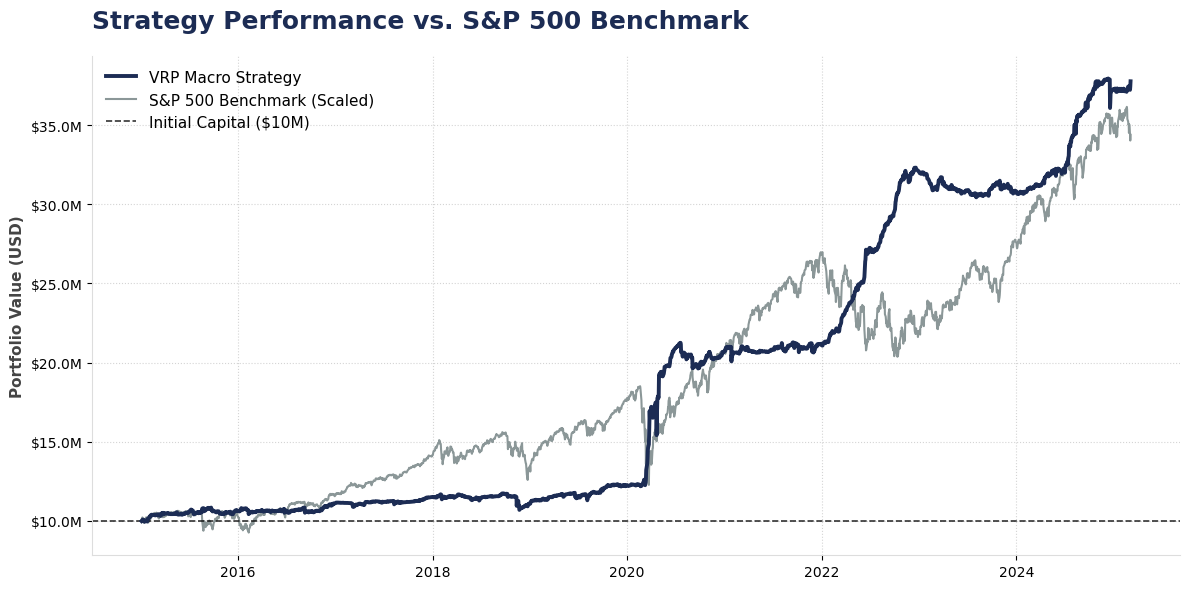

In [22]:
results_df = run_backtest(
    master_df = master_data, 
    df_rates=df_rates, 
    initial_capital=10000000, 
    leverage=2.0,
    z_threshold=0,
    start_date = '2015-01-01', end_date = '2025-12-31',
    sizing_method = 'risk_parity' 
)

lc.plot_equity_with_benchmark(results_df, data) 

In [23]:
lc.get_annual_returns(results_df, data, strategy_name="VRP Risk Parity")

,VRP Risk Parity,S&P 500 (SPY)
2015,6.60%,3.15%
2016,4.34%,12.00%
2017,3.61%,21.71%
2018,-3.61%,-4.57%
2019,10.57%,31.22%
2020,68.94%,18.33%
2021,2.36%,28.73%
2022,51.44%,-18.18%
2023,-3.86%,26.18%
2024,20.83%,24.89%


In [24]:
lc.get_benchmark_comparison_table(results_df, data, strategy_name="VRP Risk Parity")

,VRP Risk Parity,S&P 500 (SPY)
Analysis Period,2015 – 2025,2015 – 2025
Annualized Return,14.03%,12.95%
Annualized Vol,9.21%,17.56%
Sharpe Ratio,1.47,0.78
Max Drawdown,-11.79%,-33.72%
Correlation to S&P,0.147,1.000
Beta vs S&P,0.077,1.000


While absolute returns are comparable, the **VRP Macro Strategy significantly outperformed the S&P 500 over this period on a risk-adjusted basis.**
* VRP Macro achieved a **Sharpe Ratio of 1.47**, nearly doubling the benchmark's 0.78. 
* Additionally, its **near-zero Beta** confirms that its returns are uncorrelated from the S&P's, providing a diversification benefit. 

### 6.2 Volatility Benchmarks: SVXY, VXX & DBMF 
To justify its role in an institutional portfolio, our strategy must outperform other passive volatility instruments.

We compare our performance against the following Index ETFs:
* **SVXY (Short VIX):** Passive Short Volatility 
* **VXX (Long VIX):** Passive Long Volatility 
* **DBMF (Managed Futures):** Diversified Trend-Following 

In [25]:
# Call function 
styled_table, corr_matrix = lc.get_full_alpha_validation_table(results_df, data, start_date='2020-01-01', end_date=None)

display(styled_table) # Display the full 5-column table

,Strategy,Equity (SPY),Short Vol (SVXY),Long Vol (VXX),Trend (DBMF)
Analysis Period,2020 – 2025,2020 – 2025,2020 – 2025,2020 – 2025,2020 – 2025
Annualized Return,25.00%,16.14%,16.17%,-26.13%,6.31%
Annualized Vol,11.35%,20.81%,39.05%,75.31%,12.85%
Sharpe Ratio,1.97,0.72,0.38,-0.40,0.48
Max Drawdown,-11.79%,-33.72%,-62.19%,-99.08%,-20.39%


The **VRP Macro Strategy** provides **higher returns than each benchmark with a fraction of the volatility**
* SVXY (Short Vol.) returned 16.17%, but with a significant -62.19% drawdown and nearly 40% annualized volatility.
* VXX (Long Vol.) lost 26% annually. 

In [26]:
display(corr_matrix.style.background_gradient(cmap='RdBu_r', axis=None).format("{:.3f}")) # Display the expanded Correlation Matrix

,Strategy,S&P 500,Short Vol (SVXY),Long Vol (VXX),Trend (DBMF)
Strategy,1.000,0.113,0.113,-0.125,0.054
S&P 500,0.113,1.000,0.735,-0.713,0.157
Short Vol (SVXY),0.113,0.735,1.000,-0.980,0.254
Long Vol (VXX),-0.125,-0.713,-0.980,1.000,-0.265
Trend (DBMF),0.054,0.157,0.254,-0.265,1.000


In the time period 2020-2025, the strategy achieved a 1.97 Sharpe Ratio while **maintaining minimal correlation to the S&P 500.**

This suggests that the relative-value Z-score ranking is a significantly more efficient way to harvest risk premia than directional equity or trend exposure.

## 7 Conclusion
### 7.1 The Case for Cross-Asset Volatility Carry
Our analysis confirms that the Volatility Risk Premium (VRP) remains a robust and harvestable structural risk premium across diversified asset classes.

**Key Findings:**
* **Superior Risk-Adjusted Returns:** The strategy delivered a 1.97 Sharpe Ratio (2020–2025), significantly outperforming the S&P 500 (0.72) and passive volatility instruments.
* **Low Correlation & Tail Resiliance:** With a Beta of 0.077 and a correlation of 0.113 to the S&P 500, the strategy acts as a powerful diversifier. Unlike passive short-volatility ETFs (SVXY), our long-leg mitigated drawdown to just -11.79% during major market shocks.
* **Structural Edge:** The strategy's alpha is not derived from market direction but from the persistent demand for institutional hedging.

**Capacity & Liquidity Constraints:** 
* The strategy utilizes a universe of high-liquidity, large-cap ETFs and their respective ATM options markets to ensure significant institutional-grade capacity.
* At a target AUM of $10M – $100M, daily turnover remains strictly below 1% of Average Daily Volume (ADV) for efficient execution purposes. 